# Introducción a RAG

Retrieval-Augmented Generation combina la búsqueda de información con un LLM para que sus respuestas se basen en los datos de la base de datos vectorial en lugar de solo en lo que aprendió durante su entrenamiento.


<div style="width:500px">

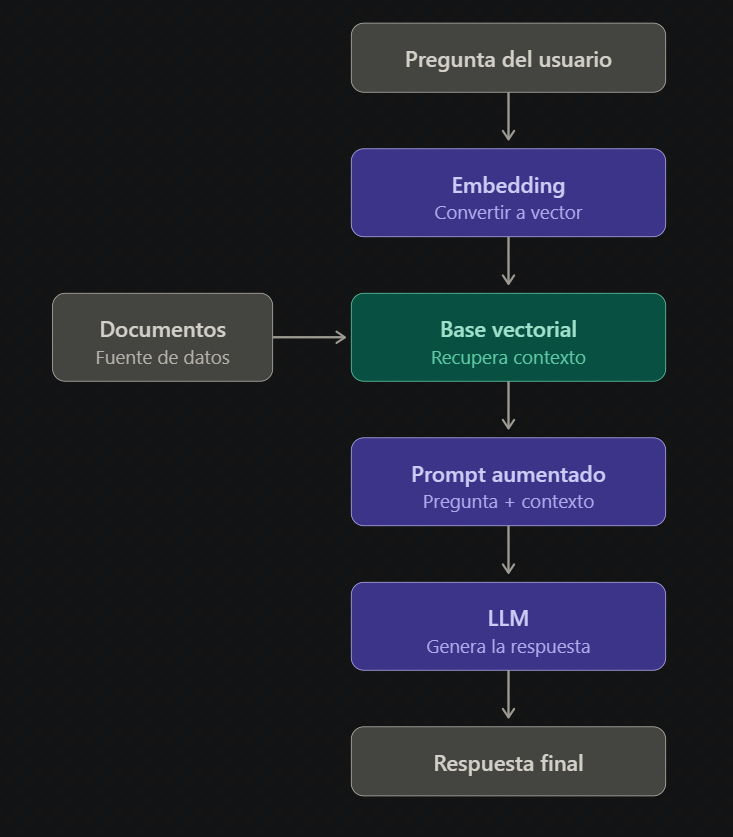

</div>

- Retriever: Embedding + Documentos + Recuperación de Texto
- Augmented: Prompt Aumentado
- Generation: Generación basada en prompt aumentado.

In [ ]:
# pip install langchain langgraph
# pip uninstall easyocr # eliminar si no se desea multimodalidad, caso contrario, instalar librerías sugeridas
# pip uninstall scikit-image # eliminar si no se desea multimodalidad, caso contrario, instalar librerías sugeridas
# pip install chromadb
# pip install sentence-transformers

In [8]:
import os

import langchain
from langchain_openai import ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer
import chromadb

from dotenv import load_dotenv

openai_key = os.getenv("OPENAI_KEY")

RuntimeError: Could not load libtorchcodec. Likely causes:
          1. FFmpeg is not properly installed in your environment. We support
             versions 4, 5, 6, 7, and 8, and we attempt to load libtorchcodec
             for each of those versions. Errors for versions not installed on
             your system are expected; only the error for your installed FFmpeg
             version is relevant. On Windows, ensure you've installed the
             "full-shared" version which ships DLLs.
          2. The PyTorch version (2.10.0+cu128) is not compatible with
             this version of TorchCodec. Refer to the version compatibility
             table:
             https://github.com/pytorch/torchcodec?tab=readme-ov-file#installing-torchcodec.
          3. Another runtime dependency; see exceptions below.

        The following exceptions were raised as we tried to load libtorchcodec:
        
[start of libtorchcodec loading traceback]
FFmpeg version 8:
Traceback (most recent cal

In [3]:
# OpenAI LangChain conection example
llm = ChatOpenAI(
    model=os.getenv("OPENAI_MODEL", "gpt-5.4-mini"),
    api_key=os.getenv("OPENAI_KEY"),
    temperature=0.7,
        model_kwargs={
        "reasoning_effort": "medium"
    }
)

response = llm.invoke("What is the capital of France?")
print(response.content) 

/home/docampor/usfq-mmia/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3687: UserWarning: Parameters {'reasoning_effort'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  if await self.run_code(code, result, async_=asy):


OpenAIError: Missing credentials. Please pass an `api_key`, `workload_identity`, `admin_api_key`, or set the `OPENAI_API_KEY` or `OPENAI_ADMIN_KEY` environment variable.

## Base de Datos Vectorial

In [4]:
# Taken from: https://github.com/chroma-core/chroma
## setup Chroma in-memory, for easy prototyping. Can add persistence easily!
client = chromadb.Client()

## Create collection. get_collection, get_or_create_collection, delete_collection also available!
try:
    client.delete_collection(name="all-my-documents")
except Exception:
    pass

collection = client.get_or_create_collection(
    name="all-my-documents",
    metadata={"hnsw:space": "cosine"} 
)

## Add docs to the collection. Can also update and delete. Row-based API coming soon!
## chromadb uses all-MiniLM-L6-v2 embedding by default
collection.add(
    documents=["This is document1", "This is document2"], # we handle tokenization, embedding, and indexing automatically. You can skip that and add your own embeddings as well
        # OJO: chunking se debe hacer manualmente
    metadatas=[{"source": "notion"}, {"source": "google-docs"}], # filter on these(?)
    ids=["doc1", "doc2"], # unique for each doc
)

## Query/search 2 most similar results. You can also .get by id
results = collection.query(
    query_texts=["document1"],
    n_results=2 # hiper-parámetro por optimizar
    # where={"metadata_field": "is_equal_to_this"}, # optional filter
    # where_document={"$contains":"search_string"}  # optional filter
)
print(results)

NameError: name 'chromadb' is not defined

Detalle importante sobre las distancias de ChromaDB:

**Similitud coseno** (cosine similarity):

$$\text{sim}(a, b) = \frac{a \cdot b}{\|a\| \|b\|} \in [-1, 1]$$

- 1 = vectores idénticos en dirección
- 0 = ortogonales
- -1 = opuestos

**Distancia coseno** (cosine distance), como la define Chroma:

$$d(a, b) = 1 - \text{sim}(a, b) \in [0, 2]$$

- 0 = idénticos
- 1 = ortogonales
- 2 = opuestos


## Métricas para retriever

Según Enevoldsen et al. (2025) se recomienda tres métricas para medir la calidad de un retriever:

- **Precision@k**: de los k documentos que recuperaste, ¿qué fracción es relevante?
- **Recall@k**: de todos los documentos relevantes que existen, ¿qué fracción capturaste en el top-k?
- **nDCG@k**: de los k documentos que recuperaste, ¿qué tan bien están *ordenados* por relevancia?

Formalmente:

**Precision@k:**

$$P@k = \frac{|\{d_1, \ldots, d_k\} \cap R_q|}{k}$$

**Recall@k:**

$$R@k = \frac{|\{d_1, \ldots, d_k\} \cap R_q|}{|R_q|}$$

En este contexto, Precision y Recall se diferencian por el denominador: Precision divide por k (cuántos documentos vemos), Recall divide por |R_q| (cuántos relevantes existen en total).

El top de MTEB basado en nDCG@k propuesto por  Enevoldsen et al. (2025) se puede encontrar en: https://huggingface.co/spaces/mteb/leaderboard el cual se encuentra constantemente evolucionando. Por esa razón los autores sugieren su uso como una referencia inicial únicamente. Recuerda comparar métricas de desempeño con costo y latencia, ¿la mejora en desempeño vale la pena desde un punto de vista de costo?

In [1]:
# Cambiar de embedding
model = SentenceTransformer(
    "all-MiniLM-L6-v2",
)

def embed(texts):
    return model.encode(texts).tolist()

collection = client.get_or_create_collection(
    name="all-my-documents",
    metadata={"hnsw:space": "cosine"},
    # embedding_function=embed,
)

NameError: name 'SentenceTransformer' is not defined

# Tarea en clase

Construir un RAG con LangChain y su LLM favorito, use los documentos provistos, ¿su RAG puede responder correctamente todas estas preguntas? - pruebe differentes embeddings

**Multi-hop (encadenar varios documentos):**
- *"¿Qué autonomía tiene el modelo que el CTO recomendó discontinuar?"* → acta → LR-100 → 90 min.
- *"¿Qué versión de la app necesito para el modelo que reemplazó al LR-100?"* → acta → LR-200 specs → v3.x.

**Temporal y condicional (dos políticas vigentes en distintos momentos):**
- *"Compré un LR-200 sin abrir hace 45 días, ¿puedo devolverlo y con qué cargo?"* → política 2024 → reembolso íntegro sin cargo.
- *"¿Y si lo hubiera comprado en febrero de 2024?"* → política 2023 → 30 días, ya fuera de plazo.

**Routing (elegir el canal correcto según el problema):**
- *"Mi LR-200 muestra error E07 que no se va al reiniciar, ¿a quién llamo?"* → incidencias dicen "fallo de hardware" → contactos → +34 900 111 222.
- *"Tengo garantía extendida y mi LR-200 no enciende, ¿qué línea uso?"* → línea preferente.

**Comparación cruzada:**
- *"¿Qué modelo del mercado ofrece mejor garantía por menos de 600 €?"* → comparativa + tabla de garantías → LR-200.

**Agregación con filtrado:**
- *"Lista todos los bugs de software del modelo estrella que ya estén resueltos."* → identificar "estrella" = LR-200 → filtrar resueltos → F-301.

El truco está en que cada documento por sí solo es insuficiente: el sistema tiene que decidir **qué consultar**, **en qué orden** y **cuándo combinar resultados** — justo lo que un agente sabe hacer y un retriever de un solo paso no.

In [9]:
all_txt_files = os.listdir("data")
all_txt_files = [i for i in all_txt_files if "txt" in i]
print(all_txt_files)

client = chromadb.Client()
splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,        # caracteres, no tokens
    chunk_overlap=10,      # solapamiento para no cortar ideas
    separators=["\n\n", "\n", ". ", " ", ""],
)

for file in all_txt_files:
    with open(os.path.join("data",file), "r", encoding="utf-8") as f:
        document_i = f.read()
    chunks = splitter.split_text(document_i)
    collection.add(
        documents=chunks,
        ids= [f"{file}_{i}" for i in range(len(chunks))]
    )

['01_producto_lr100_specs.txt', '02_producto_lr200_specs.txt', '03_politica_devoluciones_2023.txt', '04_politica_devoluciones_2024.txt', '05_acta_reunion_q3_2024.txt', '06_garantias.txt', '07_soporte_contactos.txt', '08_manual_uso_lr200.txt', '09_incidencias_conocidas.txt', '10_comparativa_competencia.txt']


In [10]:
results = collection.query(
    query_texts=["Qué autonomía tiene el modelo que el CTO recomendó discontinuar"],
    n_results=2 # hiper-parámetro por optimizar
    # where={"metadata_field": "is_equal_to_this"}, # optional filter
    # where_document={"$contains":"search_string"}  # optional filter
)
print(results)

{'ids': [['09_incidencias_conocidas.txt_4', '10_comparativa_competencia.txt_1']], 'embeddings': None, 'documents': [['. No hay solución prevista; el modelo está en proceso de discontinuación.', 'Competidor A — modelo CleanX Pro\n  Autonomía: 150 minutos']], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[None, None]], 'distances': [[0.309462308883667, 0.3672049641609192]]}


# Referencias

Enevoldsen, K., Chung, I., Kerboua, I., Kardos, M., Mathur, A., Stap, D., ... & Muennighoff, N. (2025). Mmteb: Massive multilingual text embedding benchmark. arXiv preprint arXiv:2502.13595.